# DQ4FairIM-TC — Google Colab (Dynamic Graph)


## 1 · Install & verify

In [1]:
!pip install networkx scipy -q
import torch, networkx as nx, numpy as np
print(f'PyTorch {torch.__version__} | GPU: {torch.cuda.is_available()}')
print(f'NetworkX {nx.__version__} | NumPy: {np.__version__}')

PyTorch 2.10.0+cu128 | GPU: True
NetworkX 3.6.1 | NumPy: 2.0.2


## 2 · Create folders

In [2]:
import os
for d in ['fairim/src','fairim/checkpoints','fairim/results']:
    os.makedirs(d,exist_ok=True)
print('Folders ready.')

Folders ready.


## 3 · Upload all source modules in fairim/src

## 4 · Import test

In [ ]:
import sys
sys.path.insert(0,'fairim')
from src import (
    build_hba_graph, build_sbm_graph, build_graph_pool,
    simulate_ic_communities, simulate_tc_ic,
    FairIMEnvironment, DQNAgent,
    get_adjacency_matrix, community_stats,
    evaluate_all_baselines,
)
from src.diffusion import gini_coefficient
print('All imports OK.')

All imports OK.


## 5 · Configuration


In [ ]:
# ─── Core settings ─────────────────────────────────────────
GRAPH_TYPE       = 'hba'
N_NODES          = 300
N_TRAIN_GRAPHS   = 10
BUDGET           = 10
DEADLINE         = None
IC_PROB          = 0.1
NUM_SIM_TRAIN    = 30
NUM_SIM_EVAL     = 300

# ─── Reward weights ─────────────────────────────────────────
PHI              = 1.0    # fairness weight
GAMMA_LATENCY    = 0.5

# ─── Dynamic graph settings ─────────────────────────────────
TEMPORAL_CHANGE  = 0.02   # edge change rate at episode reset()
STEP_CHANGE      = 0.005  # edge change rate per seed-selection step (continuous)

# ─── Harder test graph (exposes real fairness gaps) ─────────
HOMOPHILY        = 0.75   # was ~0.46 (default); higher = harder
MINORITY_RATIO   = 0.15   # was 0.20; smaller minority = harder

# ─── Agent ──────────────────────────────────────────────────
EMBED_DIM        = 64
S2V_ITERS        = 4
LR               = 1e-3
N_EPISODES       = 400
LOG_EVERY        = 50

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device:         {DEVICE}')
print(f'Continuous dyn: step_change={STEP_CHANGE} (per step)')
print(f'Episode dyn:    temporal_change={TEMPORAL_CHANGE} (per episode)')
print(f'Test graph:     homophily={HOMOPHILY}, minority={MINORITY_RATIO}')

Device:         cuda
Continuous dyn: step_change=0.005 (per step)
Episode dyn:    temporal_change=0.02 (per episode)
Test graph:     homophily=0.75, minority=0.15


## 6 · Build training graph pool

In [ ]:
print(f'Building {N_TRAIN_GRAPHS} graphs ({GRAPH_TYPE}, n={N_NODES}, '
      f'homophily={HOMOPHILY}, minority={MINORITY_RATIO})...')
pool = build_graph_pool(n_graphs=N_TRAIN_GRAPHS, graph_type=GRAPH_TYPE,
                        n_nodes=N_NODES, seed_start=0,
                        homophily=HOMOPHILY, minority_ratio=MINORITY_RATIO)
g0,c0 = pool[0]
community_stats(g0,c0)

Building 10 graphs (hba, n=300, homophily=0.75, minority=0.15)...

── Community Statistics ──────────────
  Group 0: size=259 (86.3%), avg_degree=8.23
  Group 1: size=41 (13.7%), avg_degree=6.05
  Homophily index: 0.208
──────────────────────────────────────



{0: {'size': 259,
  'fraction': 0.8633333333333333,
  'avg_degree': np.float64(8.23)},
 1: {'size': 41,
  'fraction': 0.13666666666666666,
  'avg_degree': np.float64(6.05)}}

## 7 · Initialise agent

In [ ]:
feature_dim = 3 + len(set(c0.values()))
print(f'Feature dim: {feature_dim}')
agent = DQNAgent(
    feature_dim=feature_dim, embed_dim=EMBED_DIM,
    n_s2v_iters=S2V_ITERS, lr=LR,
    gamma=1.0, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.992,
    memory_size=2000, batch_size=32,
    update_every=1, target_update_freq=50, device=DEVICE,
)
print(f'Agent ready (all 5 weight matrices trainable)')

Feature dim: 5
Agent ready (all 5 weight matrices trainable)


## 8 · Train — with continuous dynamic graphs

The graph evolves **between every seed selection** via `step_change_rate`.
The agent must learn policies that stay fair even as edges appear and disappear mid-episode.

In [ ]:
import time
from collections import defaultdict

history = defaultdict(list)
t0 = time.time()
print(f'Training {N_EPISODES} episodes | k={BUDGET} | phi={PHI}')
print(f'Dynamics: temporal={TEMPORAL_CHANGE}/ep, step={STEP_CHANGE}/step')

sim_fn = simulate_tc_ic if DEADLINE else simulate_ic_communities
tc_kw  = {'deadline': DEADLINE} if DEADLINE else {}

for ep in range(1, N_EPISODES+1):
    g,c = pool[(ep-1) % len(pool)]
    env = FairIMEnvironment(
        base_graph=g, communities=c, budget=BUDGET,
        deadline=DEADLINE,
        temporal_change_rate=TEMPORAL_CHANGE,
        step_change_rate=STEP_CHANGE,
        ic_prob=IC_PROB, num_sim=NUM_SIM_TRAIN,
        phi=PHI, gamma_latency=GAMMA_LATENCY,
    )
    state=env.reset(); adj=get_adjacency_matrix(env.graph)
    ep_r=0.0; done=False
    while not done:
        avail=env.available_actions()
        action=agent.select_action(state,adj,avail)
        nstate,reward,done,_=env.step(action)
        nadj=get_adjacency_matrix(env.graph)  # updated after step perturbs graph
        agent.store(state,adj,action,float(reward),nstate,nadj,done)
        agent.update()
        state=nstate; adj=nadj; ep_r+=float(reward)
    final=sim_fn(env.graph,env.seed_set,c,prob=IC_PROB,num_simulations=40,**tc_kw)
    history['ep'].append(ep)
    history['reward'].append(ep_r)
    history['outreach'].append(final['outreach'])
    history['fairness'].append(final['fairness'])
    history['disparity'].append(final['disparity'])
    history['epsilon'].append(agent.epsilon)
    if ep % LOG_EVERY == 0:
        import numpy as _np
        w=min(LOG_EVERY,ep)
        print(f'  Ep {ep:4d}/{N_EPISODES} | eps={agent.epsilon:.3f} | '
              f'Out={_np.mean(history["outreach"][-w:]):.4f} | '
              f'Fair={_np.mean(history["fairness"][-w:]):.4f} | '
              f'Disp={_np.mean(history["disparity"][-w:]):.4f} | '
              f't={time.time()-t0:.0f}s')
print(f'\nDone in {time.time()-t0:.1f}s')
agent.save('fairim/checkpoints/agent_v3.pt')
print('Checkpoint saved.')

Training 400 episodes | k=10 | phi=1.0
Dynamics: temporal=0.02/ep, step=0.005/step
  Ep   50/400 | eps=0.050 | Out=0.5550 | Fair=0.5254 | Disp=0.0510 | t=68s
  Ep  100/400 | eps=0.050 | Out=0.5593 | Fair=0.5448 | Disp=0.0990 | t=138s
  Ep  150/400 | eps=0.050 | Out=0.5568 | Fair=0.5435 | Disp=0.0536 | t=211s
  Ep  200/400 | eps=0.050 | Out=0.5615 | Fair=0.5466 | Disp=0.0399 | t=285s
  Ep  250/400 | eps=0.050 | Out=0.5562 | Fair=0.5423 | Disp=0.0459 | t=357s
  Ep  300/400 | eps=0.050 | Out=0.5585 | Fair=0.5462 | Disp=0.0415 | t=429s
  Ep  350/400 | eps=0.050 | Out=0.5584 | Fair=0.5413 | Disp=0.0439 | t=501s
  Ep  400/400 | eps=0.050 | Out=0.5514 | Fair=0.5277 | Disp=0.0347 | t=573s

Done in 573.3s
Checkpoint saved.


## 9 · Training curves

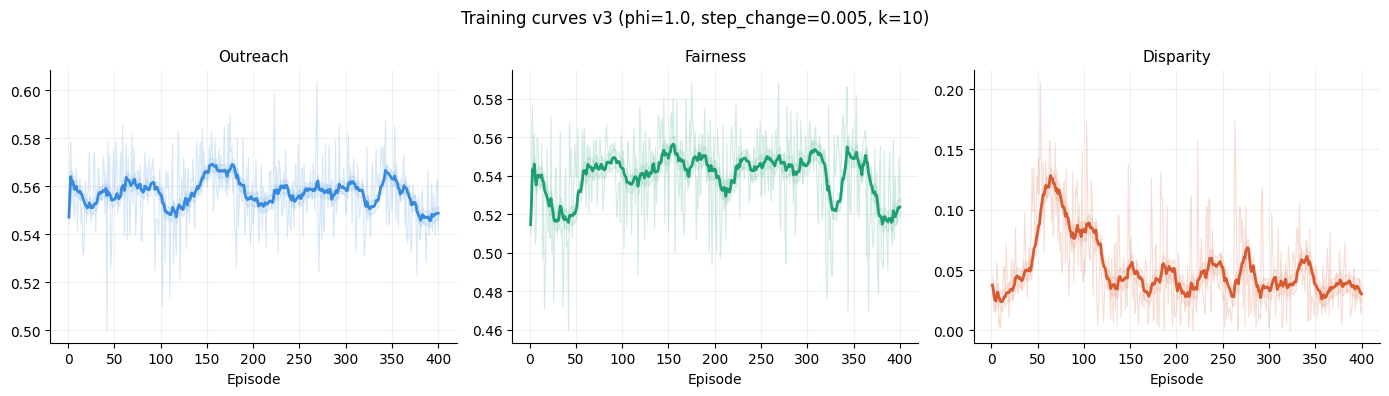

In [ ]:
import matplotlib.pyplot as plt, numpy as np

def smooth(lst,w=15): return [np.mean(lst[max(0,i-w):i+1]) for i in range(len(lst))]

fig,axes=plt.subplots(1,3,figsize=(14,4))
fig.suptitle(f'Training curves v3 (phi={PHI}, step_change={STEP_CHANGE}, k={BUDGET})',fontsize=12)
for ax,(key,label,col) in zip(axes,[
    ('outreach','Outreach','#378add'),
    ('fairness','Fairness','#1d9e75'),
    ('disparity','Disparity','#d85a30')]):
    raw=history[key]; smo=smooth(raw); eps=history['ep']
    ax.fill_between(eps,np.array(smo)-np.std(raw)*.2,
                    np.array(smo)+np.std(raw)*.2,alpha=.1,color=col)
    ax.plot(eps,raw,color=col,alpha=.2,lw=.8)
    ax.plot(eps,smo,color=col,lw=2.0)
    ax.set_title(label,fontsize=11); ax.set_xlabel('Episode'); ax.grid(alpha=.2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fairim/results/training_v3.png',dpi=150,bbox_inches='tight')
plt.show()

## 10 · Evaluate on continuous dynamic test graph

Both agent AND baselines run on the **same** continuously evolving graph.
This is a truly apples-to-apples comparison under dynamic conditions.

In [ ]:
# Build harder test graph
test_graph, test_comm = build_hba_graph(
    n=N_NODES, seed=999,
    homophily=HOMOPHILY, minority_ratio=MINORITY_RATIO)
community_stats(test_graph, test_comm)

# ── Helper: run any seed-selection method on a continuously evolving graph ──
def eval_on_dynamic(seed_fn, graph, comm, k, step_change, ic_prob, num_sim):
    """
    seed_fn: callable(graph, k, communities) -> set of seed nodes
    Evaluates after re-perturbing the graph once per seed selection,
    matching the exact dynamic conditions the agent is trained on.
    """
    env_tmp = FairIMEnvironment(graph, comm, budget=k,
                                temporal_change_rate=0.0,
                                step_change_rate=step_change,
                                ic_prob=ic_prob, num_sim=num_sim)
    env_tmp.reset()
    # Baselines choose all seeds at once on initial graph snapshot
    seeds = seed_fn(env_tmp.graph, k, comm)
    # Simulate diffusion on the evolved graph (after k perturbations)
    evolved = env_tmp.graph.copy()
    for _ in range(k):
        evolved = env_tmp._apply_temporal_change(evolved, rate=step_change)
    return simulate_ic_communities(evolved, seeds, comm,
                                   prob=ic_prob, num_simulations=num_sim)

print('Evaluating on continuous dynamic graph (step_change={})...'.format(STEP_CHANGE))
from src.baselines import degree_seeding, pagerank_seeding, parity_seeding, fair_pagerank_seeding

results = {}
for name, fn in [
    ('Degree',       lambda g,k,c: degree_seeding(g,k)),
    ('PageRank',     lambda g,k,c: pagerank_seeding(g,k)),
    ('Parity',       parity_seeding),
    ('Fair-PageRank',fair_pagerank_seeding),
]:
    print(f'  {name}...')
    results[name] = eval_on_dynamic(fn, test_graph, test_comm,
                                    BUDGET, STEP_CHANGE, IC_PROB, NUM_SIM_EVAL)

# Agent: trained for continuous dynamics, evaluated the same way
print('  DQ4FairIM-TC...')
agent.epsilon = 0.0
env_eval = FairIMEnvironment(test_graph, test_comm, budget=BUDGET,
                             temporal_change_rate=0.0,
                             step_change_rate=STEP_CHANGE,
                             ic_prob=IC_PROB, num_sim=50,
                             phi=PHI, gamma_latency=GAMMA_LATENCY)
state=env_eval.reset(); adj=get_adjacency_matrix(env_eval.graph); done=False
while not done:
    avail=env_eval.available_actions(); a=agent.select_action(state,adj,avail)
    state,_,done,_=env_eval.step(a); adj=get_adjacency_matrix(env_eval.graph)
results['DQ4FairIM-TC']=simulate_ic_communities(
    env_eval.graph, env_eval.seed_set, test_comm,
    prob=IC_PROB, num_simulations=NUM_SIM_EVAL)

print()
hdr=f'{"Method":<22}{"Outreach":>10}{"Fairness":>10}{"Disparity":>10}{"Gini":>8}'
print('─'*len(hdr)); print(hdr); print('─'*len(hdr))
for m,r in results.items():
    g_val=gini_coefficient(r.get('per_comm',{}))
    tag=' ◄' if m=='DQ4FairIM-TC' else ''
    print(f'  {m:<20}{r["outreach"]:>10.4f}{r["fairness"]:>10.4f}'
          f'{r["disparity"]:>10.4f}{g_val:>8.4f}{tag}')
print('─'*len(hdr))


── Community Statistics ──────────────
  Group 0: size=250 (83.3%), avg_degree=8.2
  Group 1: size=50 (16.7%), avg_degree=6.58
  Homophily index: 0.312
──────────────────────────────────────

Evaluating on continuous dynamic graph (step_change=0.005)...
  Degree...
  PageRank...
  Parity...
  Fair-PageRank...
  DQ4FairIM-TC...

────────────────────────────────────────────────────────────
Method                  Outreach  Fairness Disparity    Gini
────────────────────────────────────────────────────────────
  Degree                  0.5382    0.5235    0.0177  0.0083
  PageRank                0.5382    0.5235    0.0177  0.0083
  Parity                  0.5410    0.5269    0.0169  0.0079
  Fair-PageRank           0.5410    0.5269    0.0169  0.0079
  DQ4FairIM-TC            0.5356    0.5267    0.0107  0.0050 ◄
────────────────────────────────────────────────────────────


## 11 · Comparison chart

/tmp/ipykernel_14353/980750456.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.replace('-TC','\n-TC').replace('Fair-','Fair\n') for m in methods],fontsize=8)
/tmp/ipykernel_14353/980750456.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.replace('-TC','\n-TC').replace('Fair-','Fair\n') for m in methods],fontsize=8)
/tmp/ipykernel_14353/980750456.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.replace('-TC','\n-TC').replace('Fair-','Fair\n') for m in methods],fontsize=8)
/tmp/ipykernel_14353/980750456.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.rep

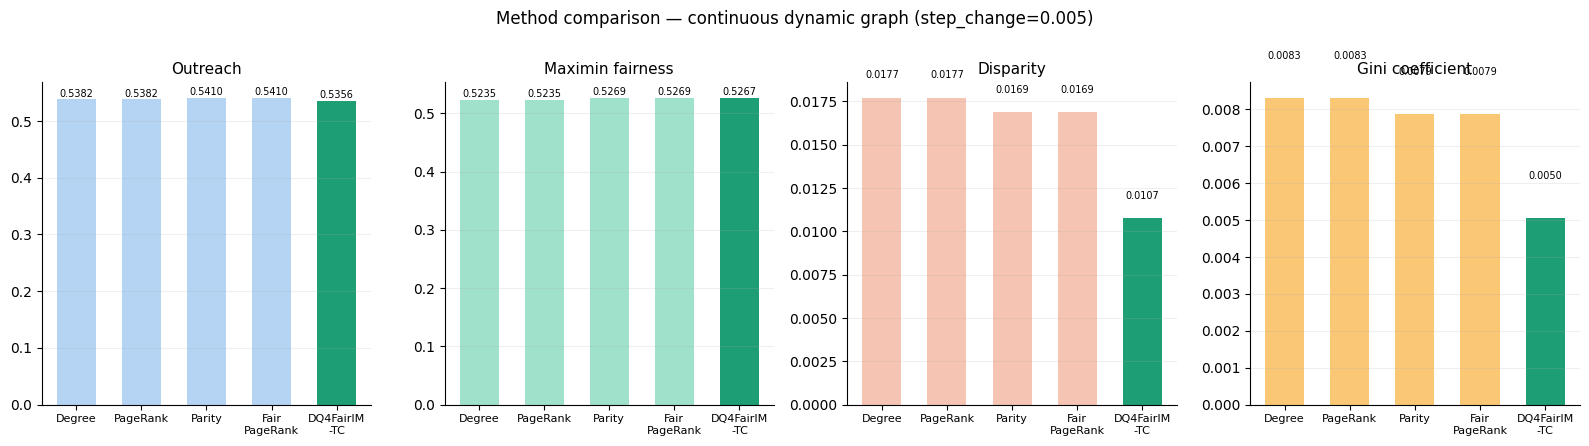

In [ ]:
import matplotlib.pyplot as plt, numpy as np

methods=list(results.keys()); AGENT='DQ4FairIM-TC'
fig,axes=plt.subplots(1,4,figsize=(16,4.5))
fig.suptitle(f'Method comparison — continuous dynamic graph (step_change={STEP_CHANGE})',fontsize=12)
for ax,(key,title,base_col) in zip(axes,[
    ('outreach','Outreach','#b5d4f4'),
    ('fairness','Maximin fairness','#9fe1cb'),
    ('disparity','Disparity','#f5c4b3'),
    (None,'Gini coefficient','#fac775')]):
    vals=[gini_coefficient(results[m].get('per_comm',{})) if key is None
          else results[m][key] for m in methods]
    bar_colors=['#1d9e75' if m==AGENT else base_col for m in methods]
    bars=ax.bar(methods,vals,color=bar_colors,width=0.6,edgecolor='none')
    ax.set_title(title,fontsize=11)
    ax.set_xticklabels([m.replace('-TC','\n-TC').replace('Fair-','Fair\n') for m in methods],fontsize=8)
    ax.grid(axis='y',alpha=0.2); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.001,
                f'{val:.4f}',ha='center',va='bottom',fontsize=7)
plt.tight_layout()
plt.savefig('fairim/results/comparison_v3.png',dpi=150,bbox_inches='tight')
plt.show()

## 12 · Temporal resilience — static vs dynamic evaluation

Compares agent performance across increasing `step_change_rate` values.
This directly answers: *does the agent trained on dynamic graphs stay resilient?*

 Step Rate  Outreach  Fairness Disparity  DSeed%
────────────────────────────────────────────────────
     0.000    0.5336    0.5175    0.0194     0.0%
     0.002    0.5282    0.5265    0.0021     0.0%
     0.005    0.5363    0.5208    0.0186    20.0%
     0.010    0.5327    0.5210    0.0140    10.0%
     0.020    0.5448    0.5429    0.0023    10.0%
     0.050    0.5311    0.5288    0.0134    10.0%


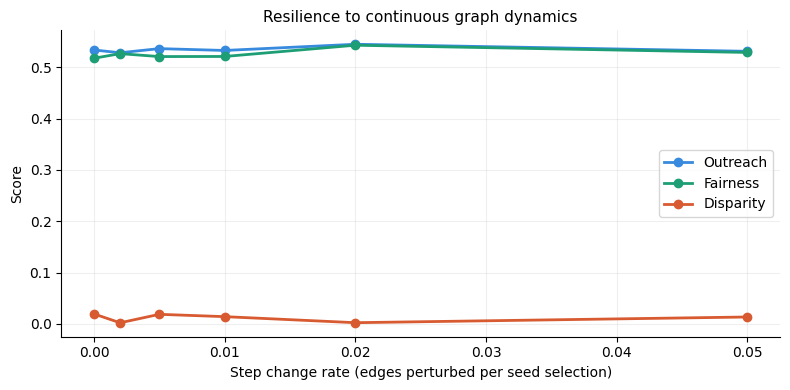

In [ ]:
step_rates=[0.0,0.002,0.005,0.01,0.02,0.05]
temp_results=[]; baseline_seed=None
print(f'{"Step Rate":>10}{"Outreach":>10}{"Fairness":>10}{"Disparity":>10}{"DSeed%":>8}')
print('─'*52)
for rate in step_rates:
    env_t=FairIMEnvironment(test_graph,test_comm,budget=BUDGET,
                            temporal_change_rate=0.0,step_change_rate=rate,
                            ic_prob=IC_PROB,num_sim=50,phi=PHI,gamma_latency=GAMMA_LATENCY)
    st=env_t.reset(); adj_t=get_adjacency_matrix(env_t.graph); d=False
    while not d:
        av=env_t.available_actions(); a=agent.select_action(st,adj_t,av)
        st,_,d,_=env_t.step(a); adj_t=get_adjacency_matrix(env_t.graph)
    res_t=simulate_ic_communities(env_t.graph,env_t.seed_set,test_comm,
                                  prob=IC_PROB,num_simulations=200)
    delta=0.0 if baseline_seed is None else \
          len(baseline_seed-env_t.seed_set)/max(len(baseline_seed),1)*100
    if baseline_seed is None: baseline_seed=set(env_t.seed_set)
    temp_results.append({'rate':rate,'outreach':res_t['outreach'],
                         'fairness':res_t['fairness'],'disparity':res_t['disparity'],'ds':delta})
    print(f'{rate:>10.3f}{res_t["outreach"]:>10.4f}{res_t["fairness"]:>10.4f}'
          f'{res_t["disparity"]:>10.4f}{delta:>8.1f}%')

import matplotlib.pyplot as plt
rates=[r['rate'] for r in temp_results]
fig,ax=plt.subplots(figsize=(8,4))
for key,col,lbl in [('outreach','#378add','Outreach'),
                     ('fairness','#1d9e75','Fairness'),
                     ('disparity','#d85a30','Disparity')]:
    ax.plot(rates,[r[key] for r in temp_results],'o-',color=col,lw=2,label=lbl)
ax.set_xlabel('Step change rate (edges perturbed per seed selection)')
ax.set_ylabel('Score'); ax.set_title('Resilience to continuous graph dynamics',fontsize=11)
ax.legend(); ax.grid(alpha=.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fairim/results/temporal_v3.png',dpi=150,bbox_inches='tight')
plt.show()

## 13 · Save & download results

In [ ]:
import json, zipfile, os
from google.colab import files

summary={'config':{'graph_type':GRAPH_TYPE,'n_nodes':N_NODES,'budget':BUDGET,
                   'phi':PHI,'n_episodes':N_EPISODES,
                   'temporal_change':TEMPORAL_CHANGE,'step_change':STEP_CHANGE,
                   'homophily':HOMOPHILY,'minority_ratio':MINORITY_RATIO},
         'final_comparison':{
             m:{'outreach':round(float(r['outreach']),4),
                'fairness':round(float(r['fairness']),4),
                'disparity':round(float(r['disparity']),4),
                'gini':round(float(gini_coefficient(r.get('per_comm',{}))),4)}
             for m,r in results.items()},
         'temporal_resilience':temp_results}
with open('fairim/results/summary_v3.json','w') as f: json.dump(summary,f,indent=2)

zip_path='fairim_results_v3.zip'
with zipfile.ZipFile(zip_path,'w') as zf:
    for fn in os.listdir('fairim/results'): zf.write(f'fairim/results/{fn}',fn)
print('Saved to fairim/results/:')
for fn in sorted(os.listdir('fairim/results')): print(f'  {fn}')
files.download(zip_path)

Saved to fairim/results/:
  comparison_v3.png
  summary_v3.json
  temporal_v3.png
  training_v3.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


**Typical runtime:** 400 episodes, n=300 → ~2 min T4 GPU / ~8 min CPU